In [1]:
# import the necessary packages

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import networkx as nx

In [2]:
# Path to the required data to analyse

open_source_outputs  =  pd.read_csv('/Users/jisha/Desktop/Sarcasm_Final/Pragmantic_Function_Identification/outputs.csv')
chatgpt_outputs = pd.read_csv('/Users/jisha/Desktop/Sarcasm_Final/Pragmantic_Function_Identification/chatgpt.csv')
gemini_outputs = pd.read_csv('/Users/jisha/Desktop/Sarcasm_Final/Pragmantic_Function_Identification/gemini.csv')

In [3]:
# Attach the labelled columns from the closed source models to the opensource_outputs data 

open_source_outputs['chatgpt'] = chatgpt_outputs.iloc[:, -1]
open_source_outputs['gemini'] = gemini_outputs.iloc[:, -1]

In [4]:
open_source_outputs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   label           906 non-null    int64 
 1   comment         906 non-null    object
 2   author          906 non-null    object
 3   subreddit       906 non-null    object
 4   score           906 non-null    int64 
 5   ups             906 non-null    int64 
 6   downs           906 non-null    int64 
 7   date            906 non-null    object
 8   created_utc     906 non-null    object
 9   parent_comment  906 non-null    object
 10  llama_temp1     906 non-null    object
 11  llama_temp0     906 non-null    object
 12  deepseek_temp0  691 non-null    object
 13  deepseek_temp1  906 non-null    object
 14  chatgpt         906 non-null    object
 15  gemini          906 non-null    object
dtypes: int64(4), object(12)
memory usage: 113.4+ KB


In [5]:
# Remove null values inside the column deepseek_temp0
combined_results = open_source_outputs.dropna(subset=['deepseek_temp0'])
combined_results.info()

<class 'pandas.core.frame.DataFrame'>
Index: 691 entries, 0 to 690
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   label           691 non-null    int64 
 1   comment         691 non-null    object
 2   author          691 non-null    object
 3   subreddit       691 non-null    object
 4   score           691 non-null    int64 
 5   ups             691 non-null    int64 
 6   downs           691 non-null    int64 
 7   date            691 non-null    object
 8   created_utc     691 non-null    object
 9   parent_comment  691 non-null    object
 10  llama_temp1     691 non-null    object
 11  llama_temp0     691 non-null    object
 12  deepseek_temp0  691 non-null    object
 13  deepseek_temp1  691 non-null    object
 14  chatgpt         691 non-null    object
 15  gemini          691 non-null    object
dtypes: int64(4), object(12)
memory usage: 91.8+ KB


In [6]:
# Save the results inside a csv file 
combined_results.to_csv('/Users/jisha/Desktop/Sarcasm_Final/Pragmantic_Function_Identification/combined_results.csv', index=False)

In [7]:
# Iterate through the rows of each llam labeled columns and get the count of unique values in each column
model_result_columns = ['llama_temp1', 'llama_temp0', 'deepseek_temp0', 'deepseek_temp1', 'chatgpt', 'gemini']

for col in model_result_columns:
    unique_values_count = combined_results[col].nunique()
    print(f"Column Name: {col} | Count of Unique Values: {unique_values_count}")

Column Name: llama_temp1 | Count of Unique Values: 262
Column Name: llama_temp0 | Count of Unique Values: 185
Column Name: deepseek_temp0 | Count of Unique Values: 277
Column Name: deepseek_temp1 | Count of Unique Values: 300
Column Name: chatgpt | Count of Unique Values: 24
Column Name: gemini | Count of Unique Values: 8


In [8]:
# Function to create a word network graph for a given label
def word_network_graph(label, ax, title):
    data_label = combined_results[combined_results['label'] == label]
    
    G = nx.Graph()
    
    # Nodes: True Label and Models (central hubs)
    label_node_name = f"True Label {label}"
    G.add_node(label_node_name, type='label', color='red')
    
    model_colors = ['blue', 'cyan', 'green', 'lime', 'orange', 'purple']
    model_color_map = dict(zip(model_result_columns, model_colors))
    for model in model_result_columns:
        G.add_node(model, type='model', color=model_color_map[model])
        
    # Edges and weighted words: Connect model to words, and model to label
    for model in model_result_columns:
        word_counts = Counter(data_label[model].dropna())
        
        # Connect Model to Label
        total_words = sum(word_counts.values())
        if total_words > 0:
            G.add_edge(model, label_node_name, weight=total_words/10, color=model_color_map[model])
        
        # Connect Model to Top N Words
        for word, count in word_counts.most_common(15): # Take top 15 words per model
            G.add_edge(model, word, weight=count/5, color=model_color_map[model])
            
    # Visualization layout
    pos = nx.spring_layout(G, k=0.3, iterations=100)
    
    # Draw nodes
    node_colors = [G.nodes[node].get('color', 'gray') for node in G.nodes()]
    node_sizes = []
    for node in G.nodes():
        if G.nodes[node].get('type') == 'label': 
            node_sizes.append(3000)
        elif G.nodes[node].get('type') == 'model': 
            node_sizes.append(1500)
        else: 
            node_sizes.append(G.degree(node) * 100)
        
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8, ax=ax)
    
    # Draw edges with respective model colors
    edges, edge_colors = zip(*[( (u,v), G[u][v]['color'] ) for u,v in G.edges()])
    nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=edge_colors, width=[G[u][v]['weight'] for u,v in G.edges()], alpha=0.5, ax=ax)
    
    # Add labels for models and common words
    labels = {node: node for node in G.nodes() if G.nodes[node].get('type') != 'word' or G.degree(node) > 5}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold', ax=ax)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')



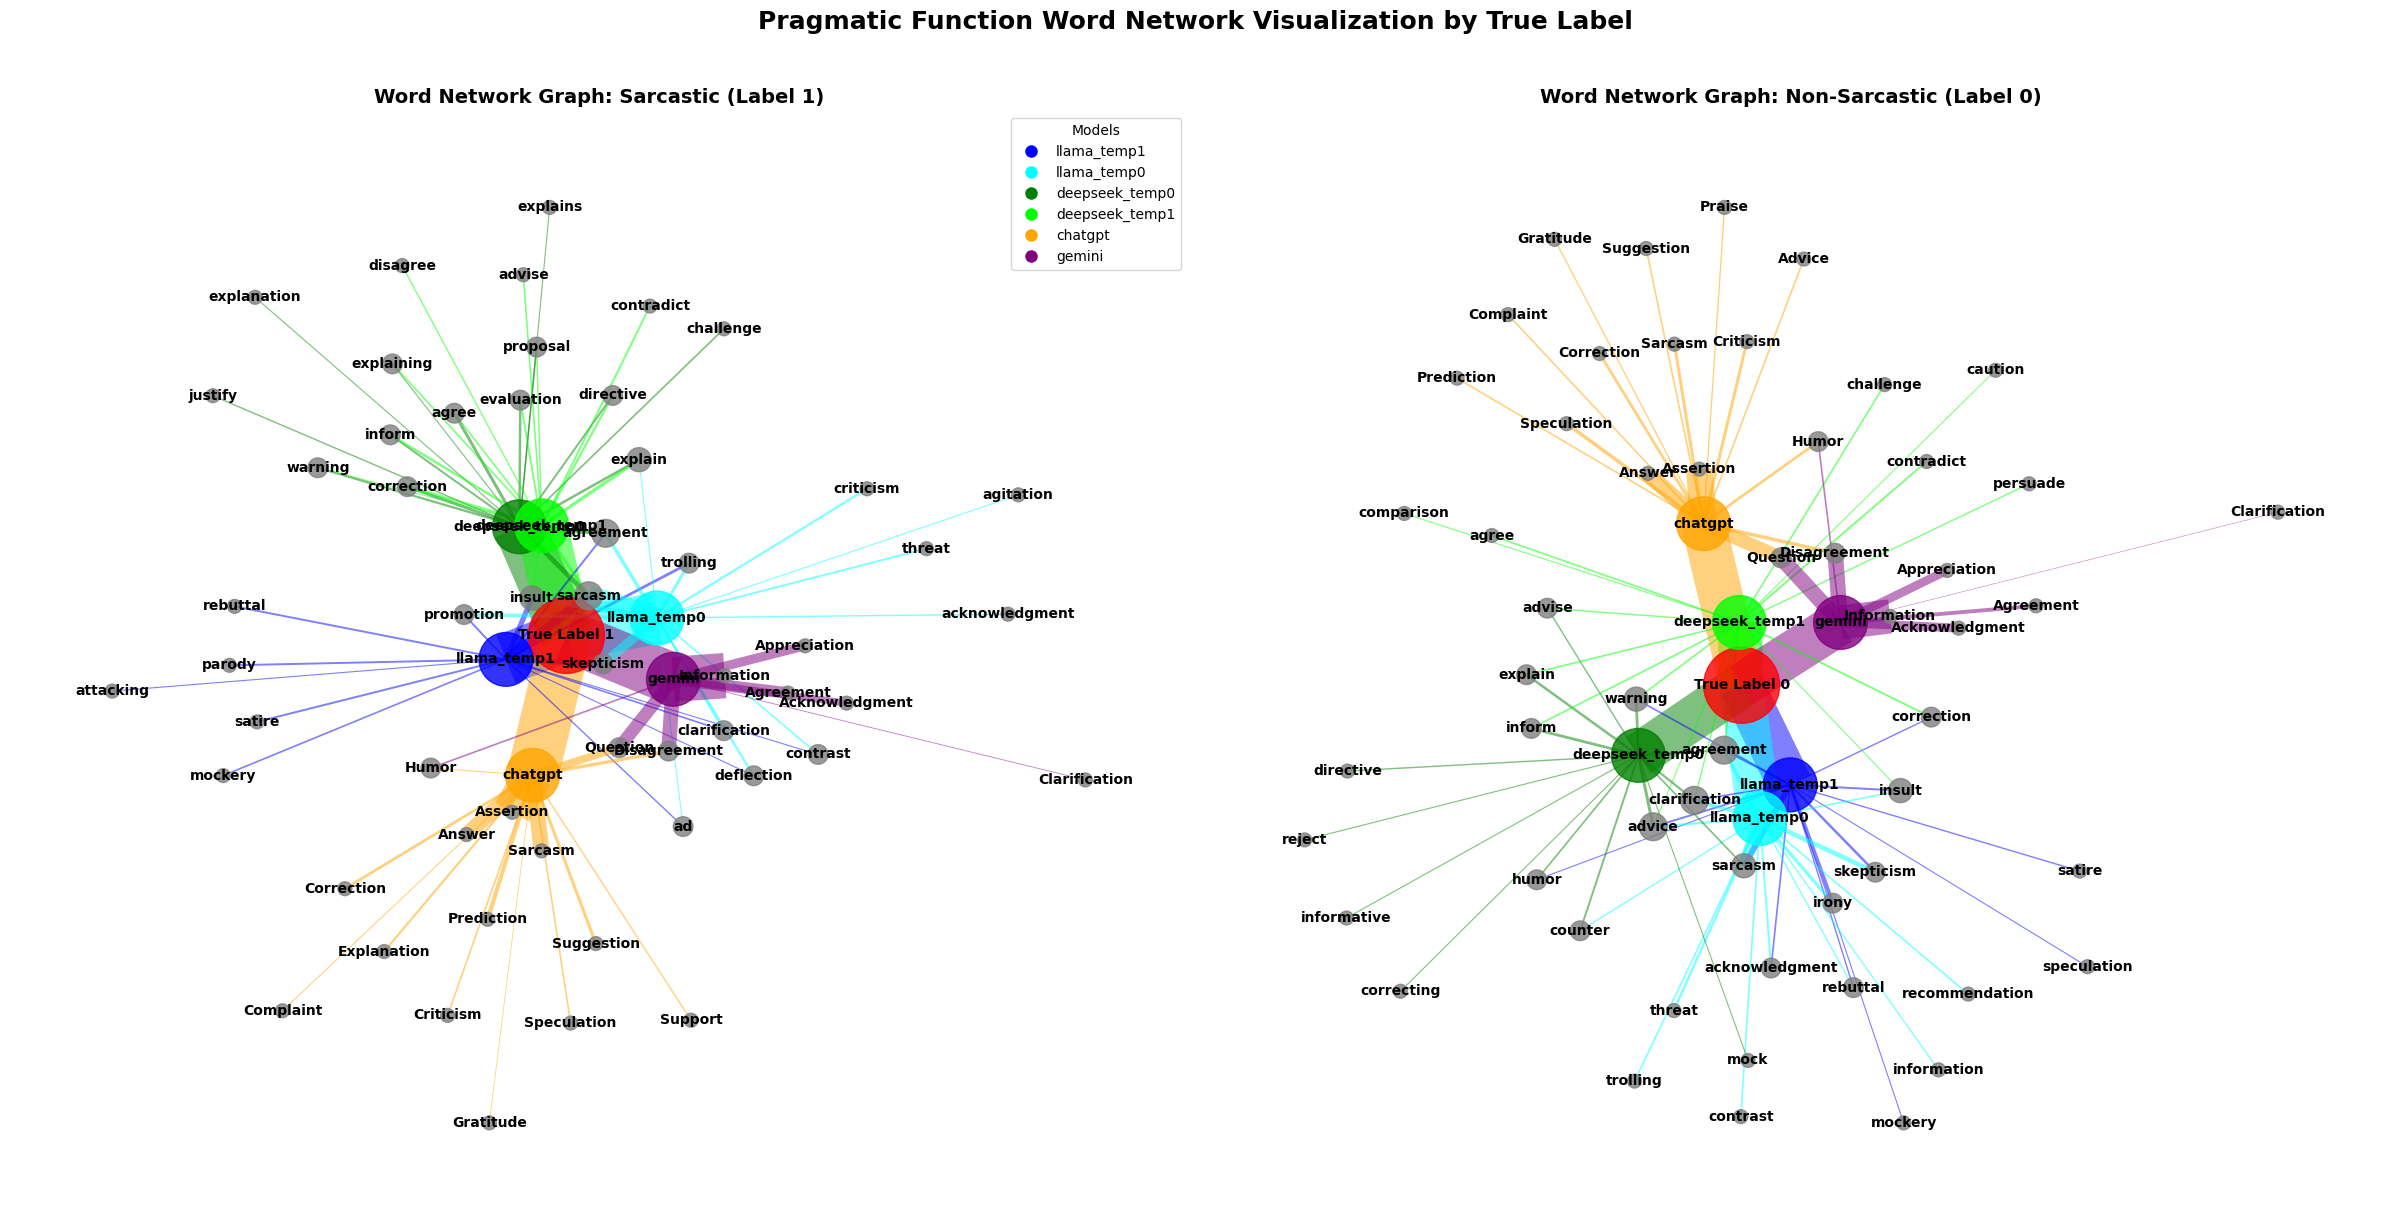

In [9]:
# Create multi-panel figure for Label 1 and Label 0
figure, axes = plt.subplots(1, 2, figsize=(24, 12))

word_network_graph(1, axes[0], 'Word Network Graph: Sarcastic (Label 1)')
word_network_graph(0, axes[1], 'Word Network Graph: Non-Sarcastic (Label 0)')

# Add custom color legend for models
model_colors_map = dict(zip(model_result_columns, ['blue', 'cyan', 'green', 'lime', 'orange', 'purple']))
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=model, markerfacecolor=color, markersize=10)
                   for model, color in model_colors_map.items()]
axes[0].legend(handles=legend_elements, loc="upper right", title="Models", fontsize=10)

plt.suptitle('Pragmatic Function Word Network Visualization by True Label', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('word_network_graphs_final.png', dpi=300, bbox_inches='tight')
plt.show()